In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 150

temperature = np.random.uniform(298, 350, n)  # K
density = np.random.uniform(900, 1200, n)     # kg/m3
viscosity = np.random.uniform(10, 100, n)     # mPa.s
mw = np.random.uniform(150, 300, n)           # molecular weight
hbd_ratio = np.random.uniform(1, 3, n)

# Create synthetic CO2 capacity relation
co2_capacity = (
    0.02 * temperature
    - 0.01 * viscosity
    + 0.0005 * density
    + 0.01 * hbd_ratio
    + np.random.normal(0, 0.5, n)
)

data = pd.DataFrame({
    "Temperature": temperature,
    "Density": density,
    "Viscosity": viscosity,
    "MolecularWeight": mw,
    "HBD_Ratio": hbd_ratio,
    "CO2_Capacity": co2_capacity
})

data.to_csv("des_co2_dataset.csv", index=False)

data.head()

,Temperature,Density,Viscosity,MolecularWeight,HBD_Ratio,CO2_Capacity
0,317.476086,1172.479766,14.651355,266.572037,1.337870,6.063334
1,347.437144,971.868567,57.821917,233.760637,1.557181,7.443907
2,336.063685,943.468462,58.657161,213.633301,1.354021,6.789225
3,329.130241,1046.835828,67.368691,285.953158,1.177405,6.236466
4,306.112969,1195.695136,75.348220,166.679622,1.241272,6.295428


In [2]:
data = pd.read_csv("des_co2_dataset.csv")
data.head()

,Temperature,Density,Viscosity,MolecularWeight,HBD_Ratio,CO2_Capacity
0,317.476086,1172.479766,14.651355,266.572037,1.337870,6.063334
1,347.437144,971.868567,57.821917,233.760637,1.557181,7.443907
2,336.063685,943.468462,58.657161,213.633301,1.354021,6.789225
3,329.130241,1046.835828,67.368691,285.953158,1.177405,6.236466
4,306.112969,1195.695136,75.348220,166.679622,1.241272,6.295428


In [3]:
data.isnull().sum()

Temperature        0
Density            0
Viscosity          0
MolecularWeight    0
HBD_Ratio          0
CO2_Capacity       0
dtype: int64

Matplotlib is building the font cache; this may take a moment.


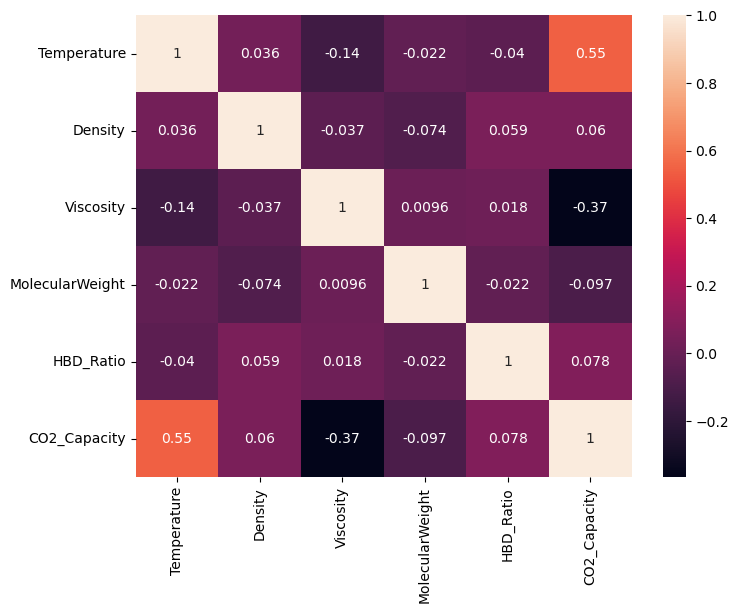

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True)
plt.show()

In [5]:
X = data.drop("CO2_Capacity", axis=1)
y = data["CO2_Capacity"]


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [8]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R2:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

R2: 0.2211423962288772
RMSE: 0.5971051067737021


In [9]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R2: 0.3329023089979314
RMSE: 0.5526071148336703


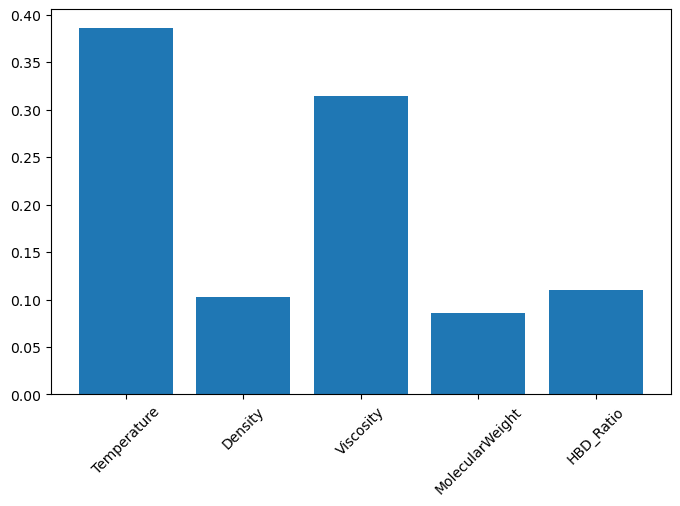

In [10]:
importance = model_rf.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.show()

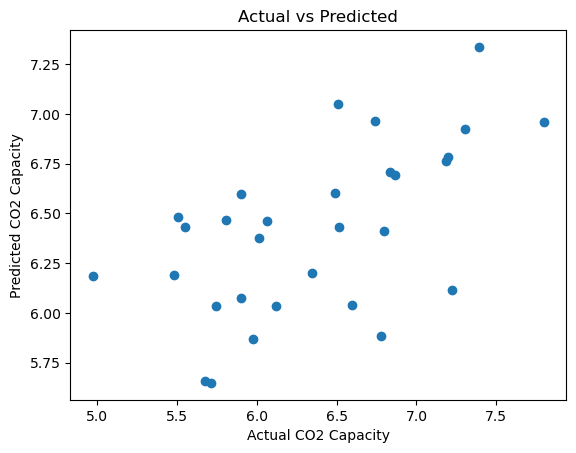

In [11]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual CO2 Capacity")
plt.ylabel("Predicted CO2 Capacity")
plt.title("Actual vs Predicted")
plt.show()